In [54]:

import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Measure Training Time
import time



In [55]:
import warnings 
warnings.filterwarnings("ignore")

In [56]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
train_df.head()

,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28


In [57]:
print("Training Dataset Shape :", train_df.shape)
print("Testing Dataset Shape  :", test_df.shape)

Training Dataset Shape : (30000, 24)
Testing Dataset Shape  : (20000, 23)


In [58]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  str    
 1   Name                         30000 non-null  str    
 2   Gender                       29947 non-null  str    
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  str    
 6   Profession                   30000 non-null  str    
 7   Type of Employment           22730 non-null  str    
 8   Location                     30000 non-null  str    
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  str    
 12  Expense Type 2               30000 non-null  str    
 13  Dependents                 

In [59]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,30000.0,40.092300,16.045129,18.00,25.0000,40.000,55.0000,65.00
Income (USD),25424.0,2630.574417,11262.723830,377.70,1650.4575,2222.435,3090.5925,1777460.21
Loan Amount Request (USD),30000.0,88826.333855,59536.949605,6048.24,41177.7550,75128.075,119964.6050,621497.82
Current Loan Expenses (USD),29828.0,400.936876,242.545375,-999.00,247.6675,375.205,521.2925,3840.88
Dependents,27507.0,2.253027,0.951162,1.00,2.0000,2.000,3.0000,14.00
Credit Score,28297.0,739.885381,72.163846,580.00,681.8800,739.820,799.1200,896.26
No. of Defaults,30000.0,0.193933,0.395384,0.00,0.0000,0.000,0.0000,1.00
Property ID,30000.0,501.934700,288.158086,1.00,251.0000,504.000,751.0000,999.00
Property Age,25150.0,2631.119440,11322.677000,377.70,1650.4500,2223.250,3091.4075,1777460.21
Property Type,30000.0,2.460067,1.118562,1.00,1.0000,2.000,3.0000,4.00


In [60]:
train_df.isnull().sum().sort_values(ascending=False)

Type of Employment             7270
Property Age                   4850
Income (USD)                   4576
Dependents                     2493
Credit Score                   1703
Income Stability               1683
Has Active Credit Card         1566
Property Location               356
Loan Sanction Amount (USD)      340
Current Loan Expenses (USD)     172
Gender                           53
Property Price                    0
Co-Applicant                      0
Property Type                     0
Property ID                       0
Customer ID                       0
No. of Defaults                   0
Name                              0
Expense Type 1                    0
Loan Amount Request (USD)         0
Location                          0
Profession                        0
Age                               0
Expense Type 2                    0
dtype: int64

In [61]:
print("Duplicate Rows :", train_df.duplicated().sum())

Duplicate Rows : 0


In [62]:
target = "Loan Sanction Amount (USD)"

print(train_df[target].describe().T)

count     29660.000000
mean      47649.342208
std       48221.146686
min        -999.000000
25%           0.000000
50%       35209.395000
75%       74261.250000
max      481907.320000
Name: Loan Sanction Amount (USD), dtype: float64


In [63]:
X = train_df.drop(columns=target)
y = train_df[target]

In [64]:
print(X.shape)
print(y.shape)


(30000, 23)
(30000,)


# Data Preprocessing

In this section, we identify numerical and categorical features, check for missing values, and prepare the dataset for machine learning models.

In [65]:
# ================================
# Identify Feature Types
# ================================

# Numerical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Number of Numerical Features :", len(numerical_cols))
print("Number of Categorical Features :", len(categorical_cols))

print("\nNumerical Features:")
print(numerical_cols)

print("\nCategorical Features:")
print(categorical_cols)

# ================================
# Check Missing Values
# ================================

missing_values = X.isnull().sum().sort_values(ascending=False)


print("\nColumns with Missing Values:")
display(missing_values)

Number of Numerical Features : 12
Number of Categorical Features : 11

Numerical Features:
['Age', 'Income (USD)', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Dependents', 'Credit Score', 'No. of Defaults', 'Property ID', 'Property Age', 'Property Type', 'Co-Applicant', 'Property Price']

Categorical Features:
['Customer ID', 'Name', 'Gender', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2', 'Has Active Credit Card', 'Property Location']

Columns with Missing Values:


Type of Employment             7270
Property Age                   4850
Income (USD)                   4576
Dependents                     2493
Credit Score                   1703
Income Stability               1683
Has Active Credit Card         1566
Property Location               356
Current Loan Expenses (USD)     172
Gender                           53
Customer ID                       0
No. of Defaults                   0
Co-Applicant                      0
Property Type                     0
Property ID                       0
Expense Type 1                    0
Expense Type 2                    0
Name                              0
Loan Amount Request (USD)         0
Location                          0
Profession                        0
Age                               0
Property Price                    0
dtype: int64

# Handling Missing Values

Missing values are handled separately for numerical and categorical features to ensure the dataset is complete before encoding and feature scaling.

In [66]:
print("Missing values in y:", y.isnull().sum())

Missing values in y: 340


In [67]:
# Keep only rows where y is not missing
valid_index = y.notna()

X = X.loc[valid_index].reset_index(drop=True)
y = y.loc[valid_index].reset_index(drop=True)

print("Missing values in y:", y.isnull().sum())
print("New X shape:", X.shape)
print("New y shape:", y.shape)

Missing values in y: 0
New X shape: (29660, 23)
New y shape: (29660,)


In [68]:
# Fill numerical columns with Median
for col in numerical_cols:
    X[col] = X[col].fillna(X[col].median())

# Fill categorical columns with Mode
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# Check missing values
print("Total Missing Values After Imputation:", X.isnull().sum().sum())

Total Missing Values After Imputation: 0


# Encoding Categorical Variables

High-cardinality categorical features are removed to reduce memory usage, while the remaining categorical features are encoded using One-Hot Encoding.

In [69]:
for col in categorical_cols:
    print(f"{col:<35} {X[col].nunique()}")

Customer ID                         29660
Name                                29660
Gender                              2
Income Stability                    2
Profession                          8
Type of Employment                  18
Location                            3
Expense Type 1                      2
Expense Type 2                      2
Has Active Credit Card              3
Property Location                   3


In [70]:

high_cardinality = [
    col for col in categorical_cols
    if X[col].nunique() > 50
]

print("Dropped Columns:", high_cardinality)

X.drop(columns=high_cardinality, inplace=True)

categorical_cols = [
    col for col in categorical_cols
    if col not in high_cardinality
]

Dropped Columns: ['Customer ID', 'Name']


# Encoding Categorical Variables

Categorical features are converted into numerical representations using One-Hot Encoding so that they can be used by machine learning algorithms.

In [71]:
import pandas as pd
# Encode all categorical features
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)


print("Shape After Encoding :", X.shape)

# Display first five rows
display(X.head())

Shape After Encoding : (29660, 46)


,Age,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property ID,Property Age,Property Type,...,Type of Employment_Security staff,Type of Employment_Waiters/barmen staff,Location_Semi-Urban,Location_Urban,Expense Type 1_Y,Expense Type 2_Y,Has Active Credit Card_Inactive,Has Active Credit Card_Unpossessed,Property Location_Semi-Urban,Property Location_Urban
0,56,1933.05,72809.58,241.08,3.0,809.44,0,746,1933.050,4,...,0,0,1,0,0,0,0,0,0,0
1,32,4952.91,46837.47,495.81,1.0,780.40,0,608,4952.910,2,...,0,0,1,0,0,1,0,1,0,0
2,65,988.19,45593.04,171.95,1.0,833.15,0,546,988.190,2,...,0,0,1,0,0,1,0,1,0,1
3,65,2223.30,80057.92,298.54,2.0,832.70,1,890,2223.965,2,...,0,0,0,0,0,1,0,1,1,0
4,31,2614.77,113858.89,491.41,2.0,745.55,1,715,2614.770,4,...,0,0,1,0,0,1,0,0,1,0


# Feature Scaling

Standardize the numerical features so that all variables have a similar scale. This improves the performance of regularized regression models such as Ridge, Lasso, and Elastic Net.

In [72]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Shape After Scaling :", X_scaled.shape)

# Display first five rows
display(X_scaled.head())

Shape After Scaling : (29660, 46)


,Age,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property ID,Property Age,Property Type,...,Type of Employment_Security staff,Type of Employment_Waiters/barmen staff,Location_Semi-Urban,Location_Urban,Expense Type 1_Y,Expense Type 2_Y,Has Active Credit Card_Inactive,Has Active Credit Card_Unpossessed,Property Location_Semi-Urban,Property Location_Urban
0,0.990718,-0.061011,-0.268703,-0.660918,0.839226,0.992845,-0.490710,0.847174,-0.060702,1.376616,...,-0.14048,-0.070816,0.625602,-0.339357,-0.749912,-1.433272,-0.679031,-0.664549,-0.745856,-0.666817
1,-0.504632,0.228599,-0.705356,0.393489,-1.347686,0.578522,-0.490710,0.368267,0.228938,-0.411213,...,-0.14048,-0.070816,0.625602,-0.339357,-0.749912,0.697704,-0.679031,1.504780,-0.745856,-0.666817
2,1.551474,-0.151625,-0.726278,-0.947068,-1.347686,1.331123,-0.490710,0.153105,-0.151325,-0.411213,...,-0.14048,-0.070816,0.625602,-0.339357,-0.749912,0.697704,-0.679031,1.504780,-0.745856,1.499662
3,1.551474,-0.033176,-0.146842,-0.423073,-0.254230,1.324703,2.037863,1.346904,-0.032800,-0.411213,...,-0.14048,-0.070816,-1.598461,-0.339357,-0.749912,0.697704,-0.679031,1.504780,1.340741,-0.666817
4,-0.566939,0.004367,0.421433,0.375276,-0.254230,0.081305,2.037863,0.739593,0.004683,1.376616,...,-0.14048,-0.070816,0.625602,-0.339357,-0.749912,0.697704,-0.679031,-0.664549,1.340741,-0.666817


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of the target variable and the relationships between important features before training the regression models.

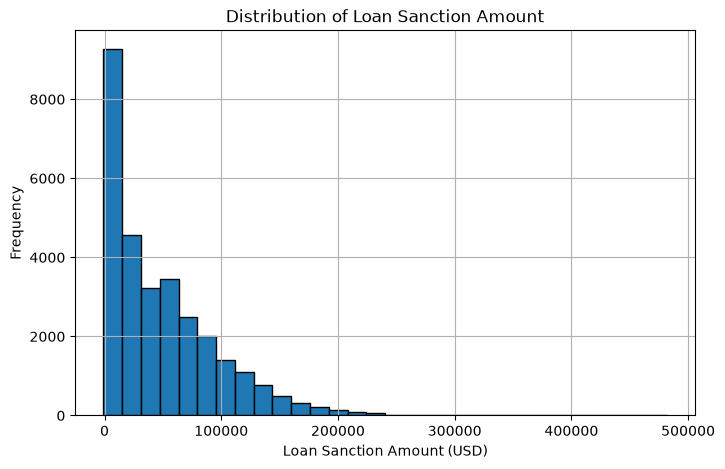

In [73]:
# Target Variable Distribution
plt.figure(figsize=(8,5))

plt.hist(y, bins=30, edgecolor='black')

plt.title("Distribution of Loan Sanction Amount")
plt.xlabel("Loan Sanction Amount (USD)")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

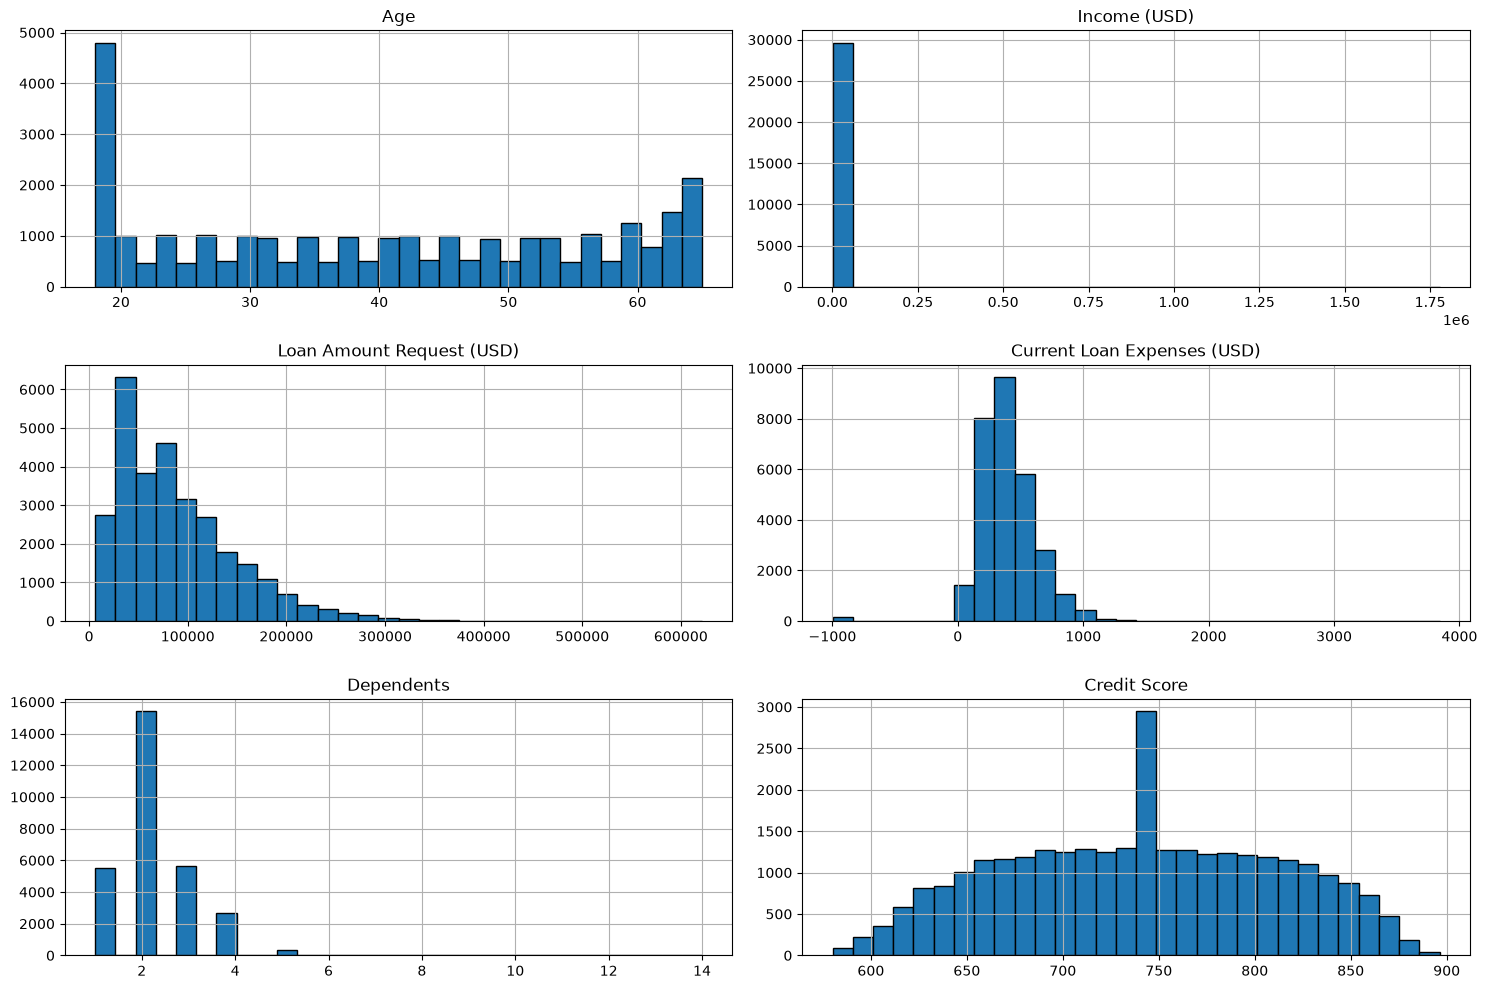

In [74]:
# Distribution of Numerical Features

selected_features = numerical_cols[:6]

X[selected_features].hist(
    figsize=(15,10),
    bins=30,
    edgecolor='black'
)

plt.tight_layout()
plt.show()

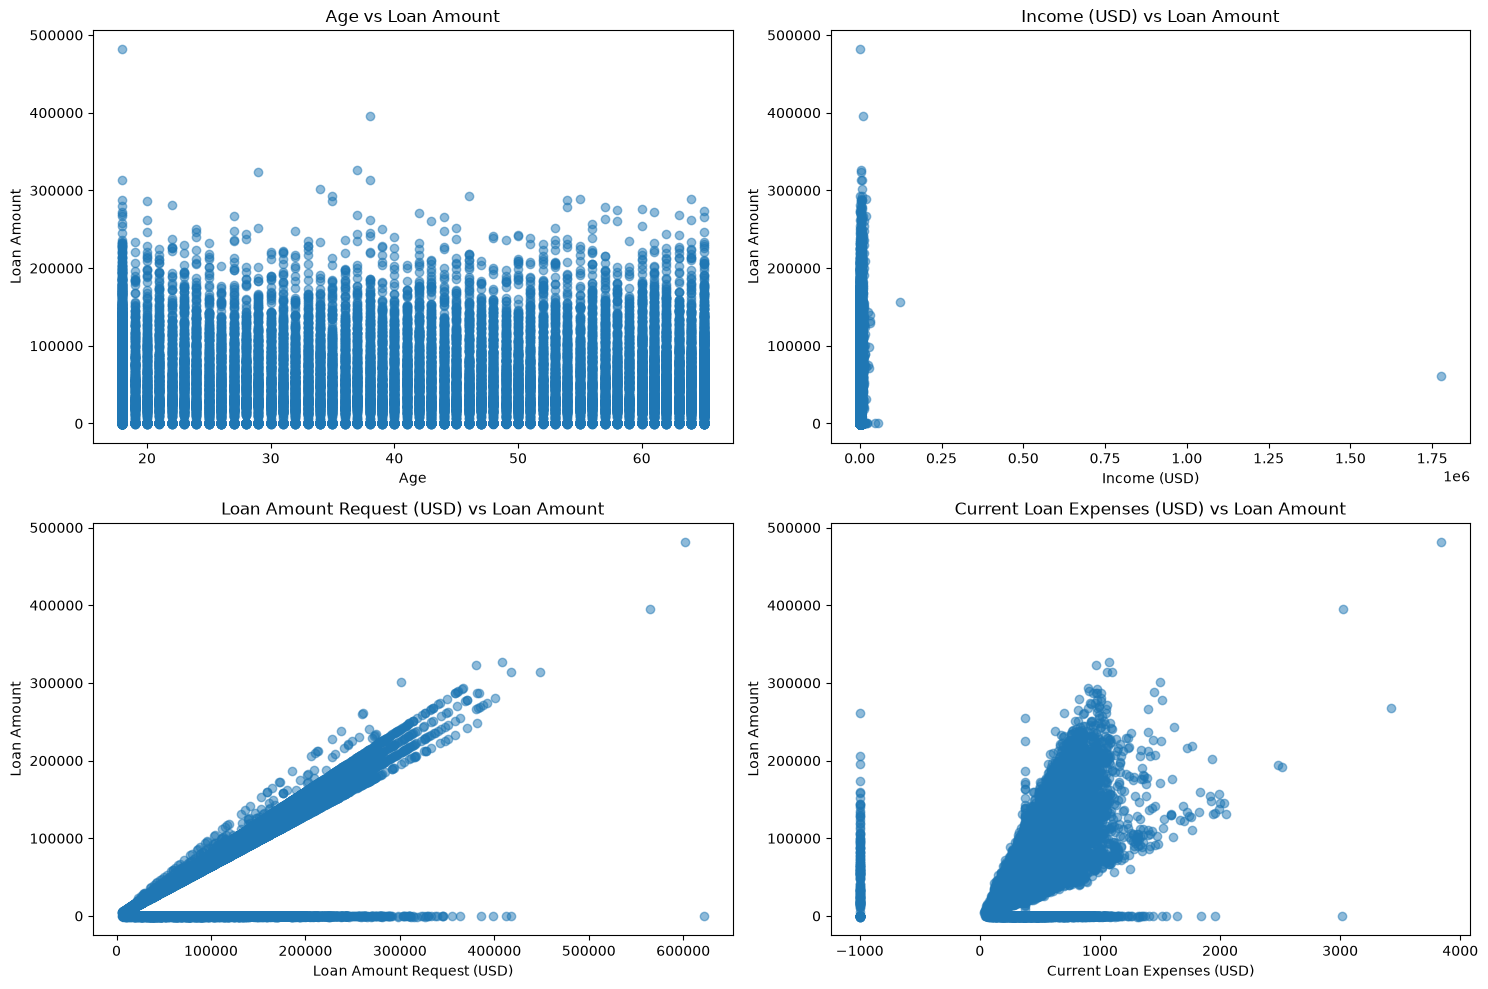

In [75]:
# Feature vs Target Relationship

selected_features = numerical_cols[:4]

plt.figure(figsize=(15,10))

for i, feature in enumerate(selected_features):

    plt.subplot(2,2,i+1)

    plt.scatter(
        X[feature],
        y,
        alpha=0.5
    )

    plt.xlabel(feature)
    plt.ylabel("Loan Amount")
    plt.title(f"{feature} vs Loan Amount")

plt.tight_layout()
plt.show()

# Train-Test Split

The dataset is divided into training and testing sets to evaluate the performance of regression models on unseen data.

In [76]:
# Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (23728, 46)
Testing Features  : (5932, 46)
Training Target   : (23728,)
Testing Target    : (5932,)


# Linear Regression

Train the baseline Linear Regression model, make predictions on the test set, and evaluate its performance using standard regression metrics.

In [77]:
# Linear Regression Model

linear_model = LinearRegression()

start_time = time.time()
linear_model.fit(X_train, y_train)

end_time = time.time()

training_time = end_time - start_time

y_pred_linear = linear_model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)

# Display Results
print("="*50)
print("Linear Regression Performance")
print("="*50)

print(f"Training Time : {training_time:.4f} seconds")
print(f"MAE           : {mae:.4f}")
print(f"MSE           : {mse:.4f}")
print(f"RMSE          : {rmse:.4f}")
print(f"R² Score      : {r2:.4f}")

Linear Regression Performance
Training Time : 0.0531 seconds
MAE           : 21591.6607
MSE           : 1018993443.4582
RMSE          : 31921.6767
R² Score      : 0.5511


# Predicted vs Actual Values

Compare the actual target values with the predicted values generated by the Linear Regression model.

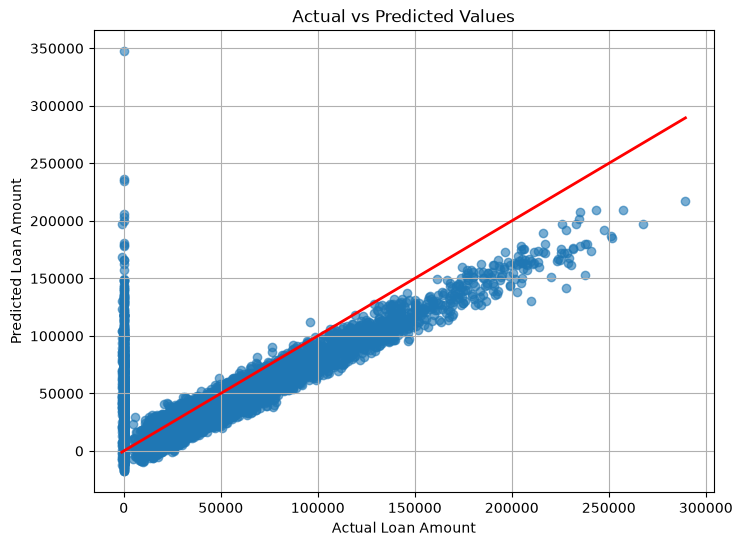

In [79]:
# Predicted vs Actual Plot

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_linear, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")

plt.grid(True)

plt.show()

# Residual Plot


The residual plot is used to analyze the prediction errors of the Linear Regression model. A good regression model should have residuals randomly scattered around zero without any clear pattern.

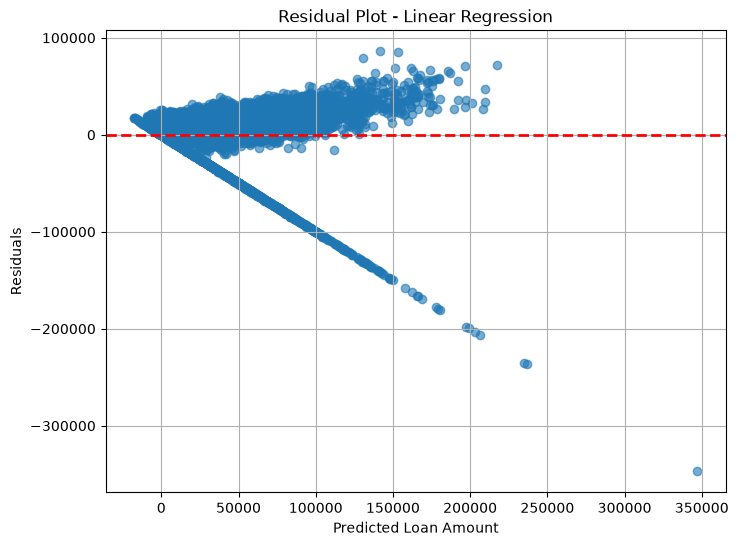

In [84]:

# Residual Plot

# Calculate residuals
residuals = y_test - y_pred_linear

plt.figure(figsize=(8,6))

plt.scatter(y_pred_linear, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title("Residual Plot - Linear Regression")
plt.xlabel("Predicted Loan Amount")
plt.ylabel("Residuals")

plt.grid(True)

plt.show()

# Ridge Regression

Ridge Regression applies L2 regularization to reduce model complexity and improve generalization by shrinking the regression coefficients.

In [85]:
ridge_model = Ridge(alpha=1.0)
start_time = time.time()
ridge_model.fit(X_train, y_train)

end_time = time.time()

ridge_training_time = end_time - start_time
y_pred_ridge = ridge_model.predict(X_test)

# Evaluation Metrics
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, y_pred_ridge)

# Display Results
print("=" * 50)
print("Ridge Regression Performance")
print("=" * 50)

print(f"Training Time : {ridge_training_time:.4f} seconds")
print(f"MAE           : {ridge_mae:.4f}")
print(f"MSE           : {ridge_mse:.4f}")
print(f"RMSE          : {ridge_rmse:.4f}")
print(f"R² Score      : {ridge_r2:.4f}")

Ridge Regression Performance
Training Time : 0.0420 seconds
MAE           : 21586.0148
MSE           : 1018839299.0146
RMSE          : 31919.2622
R² Score      : 0.5511


# Hyperparameter Tuning - Ridge Regression

Grid Search with 5-Fold Cross Validation is used to determine the optimal regularization parameter (alpha) for Ridge Regression.

In [86]:

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

# Grid Search
ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

# Best Parameters
print("Best Alpha :", ridge_grid.best_params_)
print("Best Cross Validation R² :", ridge_grid.best_score_)

Best Alpha : {'alpha': 100}
Best Cross Validation R² : 0.5731056751343926


# Ridge Regression with Best Hyperparameter

Train the Ridge Regression model using the optimal alpha value obtained from Grid Search and evaluate its performance.

In [87]:

best_ridge = ridge_grid.best_estimator_
start_time = time.time()

best_ridge.fit(X_train, y_train)

end_time = time.time()

ridge_training_time = end_time - start_time

# Prediction
y_pred_ridge = best_ridge.predict(X_test)

# Metrics
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("="*50)
print("Tuned Ridge Regression Performance")
print("="*50)

print(f"Best Alpha     : {ridge_grid.best_params_['alpha']}")
print(f"Training Time  : {ridge_training_time:.4f} seconds")
print(f"MAE            : {ridge_mae:.4f}")
print(f"MSE            : {ridge_mse:.4f}")
print(f"RMSE           : {ridge_rmse:.4f}")
print(f"R² Score       : {ridge_r2:.4f}")

Tuned Ridge Regression Performance
Best Alpha     : 100
Training Time  : 0.0305 seconds
MAE            : 21588.9183
MSE            : 1017752734.8403
RMSE           : 31902.2371
R² Score       : 0.5516


# Lasso Regression

Lasso Regression applies L1 regularization, which shrinks coefficients and can eliminate less important features by setting their coefficients to zero.

In [88]:

lasso_model = Lasso(alpha=1.0, max_iter=10000)
start_time = time.time()
lasso_model.fit(X_train, y_train)

end_time = time.time()

lasso_training_time = end_time - start_time

y_pred_lasso = lasso_model.predict(X_test)

# Evaluation Metrics
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("="*50)
print("Lasso Regression Performance")
print("="*50)

print(f"Training Time : {lasso_training_time:.4f} seconds")
print(f"MAE           : {lasso_mae:.4f}")
print(f"MSE           : {lasso_mse:.4f}")
print(f"RMSE          : {lasso_rmse:.4f}")
print(f"R² Score      : {lasso_r2:.4f}")

Lasso Regression Performance
Training Time : 5.8523 seconds
MAE           : 21583.1641
MSE           : 1018783503.8247
RMSE          : 31918.3882
R² Score      : 0.5512


# Hyperparameter Tuning - Lasso Regression

Grid Search with 5-Fold Cross Validation is used to determine the optimal alpha value for the Lasso Regression model.

In [89]:

lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=lasso_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Best Alpha :", lasso_grid.best_params_)
print("Best Cross Validation R² :", lasso_grid.best_score_)

Best Alpha : {'alpha': 10}
Best Cross Validation R² : 0.5698163447174325


# Lasso Regression with Best Hyperparameter

Train the Lasso Regression model using the optimal alpha value obtained from Grid Search and evaluate its performance.

In [90]:

best_lasso = lasso_grid.best_estimator_

start_time = time.time()

best_lasso.fit(X_train, y_train)

end_time = time.time()

lasso_training_time = end_time - start_time

y_pred_lasso = best_lasso.predict(X_test)

lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("="*50)
print("Tuned Lasso Regression Performance")
print("="*50)

print(f"Best Alpha     : {lasso_grid.best_params_['alpha']}")
print(f"Training Time  : {lasso_training_time:.4f} seconds")
print(f"MAE            : {lasso_mae:.4f}")
print(f"MSE            : {lasso_mse:.4f}")
print(f"RMSE           : {lasso_rmse:.4f}")
print(f"R² Score       : {lasso_r2:.4f}")

Tuned Lasso Regression Performance
Best Alpha     : 10
Training Time  : 0.1454 seconds
MAE            : 21568.7939
MSE            : 1018418419.2907
RMSE           : 31912.6686
R² Score       : 0.5513


# Elastic Net Regression

Elastic Net combines both L1 and L2 regularization techniques. It helps reduce overfitting while also performing feature selection.

In [91]:

elastic_model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    max_iter=10000,
    random_state=42
)

# Training Time
start_time = time.time()

# Train Model
elastic_model.fit(X_train, y_train)

end_time = time.time()

elastic_training_time = end_time - start_time

# Prediction
y_pred_elastic = elastic_model.predict(X_test)

# Evaluation Metrics
elastic_mae = mean_absolute_error(y_test, y_pred_elastic)
elastic_mse = mean_squared_error(y_test, y_pred_elastic)
elastic_rmse = np.sqrt(elastic_mse)
elastic_r2 = r2_score(y_test, y_pred_elastic)

print("="*50)
print("Elastic Net Regression Performance")
print("="*50)

print(f"Training Time : {elastic_training_time:.4f} seconds")
print(f"MAE           : {elastic_mae:.4f}")
print(f"MSE           : {elastic_mse:.4f}")
print(f"RMSE          : {elastic_rmse:.4f}")
print(f"R² Score      : {elastic_r2:.4f}")

Elastic Net Regression Performance
Training Time : 0.0336 seconds
MAE           : 23071.8988
MSE           : 1067827214.7480
RMSE          : 32677.6256
R² Score      : 0.5295


# Hyperparameter Tuning - Elastic Net

Grid Search with 5-Fold Cross Validation is performed to find the optimal values of alpha and l1_ratio for the Elastic Net model.

In [92]:

elastic_params = {
    'alpha': [0.01, 0.1, 1, 10],
    'l1_ratio': [0.2, 0.5, 0.8]
}

elastic_grid = GridSearchCV(
    estimator=ElasticNet(max_iter=10000, random_state=42),
    param_grid=elastic_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

elastic_grid.fit(X_train, y_train)

print("Best Parameters :", elastic_grid.best_params_)
print("Best Cross Validation R² :", elastic_grid.best_score_)

Best Parameters : {'alpha': 0.1, 'l1_ratio': 0.5}
Best Cross Validation R² : 0.5827256020499423


# Elastic Net Regression with Best Hyperparameters

Train the Elastic Net model using the best values of alpha and l1_ratio obtained from Grid Search and evaluate its performance.

In [93]:

best_elastic = elastic_grid.best_estimator_

start_time = time.time()

best_elastic.fit(X_train, y_train)

end_time = time.time()

elastic_training_time = end_time - start_time

y_pred_elastic = best_elastic.predict(X_test)

elastic_mae = mean_absolute_error(y_test, y_pred_elastic)
elastic_mse = mean_squared_error(y_test, y_pred_elastic)
elastic_rmse = np.sqrt(elastic_mse)
elastic_r2 = r2_score(y_test, y_pred_elastic)

print("="*50)
print("Tuned Elastic Net Performance")
print("="*50)

print(f"Best Parameters : {elastic_grid.best_params_}")
print(f"Training Time   : {elastic_training_time:.4f} seconds")
print(f"MAE             : {elastic_mae:.4f}")
print(f"MSE             : {elastic_mse:.4f}")
print(f"RMSE            : {elastic_rmse:.4f}")
print(f"R² Score        : {elastic_r2:.4f}")

Tuned Elastic Net Performance
Best Parameters : {'alpha': 0.1, 'l1_ratio': 0.5}
Training Time   : 0.1489 seconds
MAE             : 21756.4318
MSE             : 1019381662.1045
RMSE            : 31927.7569
R² Score        : 0.5509


# Performance Comparison of Regression Models

Compare the performance of Linear Regression, Ridge Regression, Lasso Regression, and Elastic Net Regression using evaluation metrics.

In [95]:

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net"
    ],
    "MAE": [
        mae,
        ridge_mae,
        lasso_mae,
        elastic_mae
    ],
    "MSE": [
        mse,
        ridge_mse,
        lasso_mse,
        elastic_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse
    ],
    "R² Score": [
        r2,
        ridge_r2,
        lasso_r2,
        elastic_r2
    ],
    "Training Time (s)": [
        training_time,
        ridge_training_time,
        lasso_training_time,
        elastic_training_time
    ]
})

comparison_df = comparison_df.round(4)

display(comparison_df)

,Model,MAE,MSE,RMSE,R² Score,Training Time (s)
0,Linear Regression,21591.6607,1.018993e+09,31921.6767,0.5511,0.0531
1,Ridge Regression,21588.9183,1.017753e+09,31902.2371,0.5516,0.0305
2,Lasso Regression,21568.7939,1.018418e+09,31912.6686,0.5513,0.1454
3,Elastic Net,21756.4318,1.019382e+09,31927.7569,0.5509,0.1489


# Coefficient Comparison

Compare the coefficients learned by Linear Regression, Ridge Regression, Lasso Regression, and Elastic Net to analyze the effect of regularization.

<Figure size 1500x700 with 0 Axes>

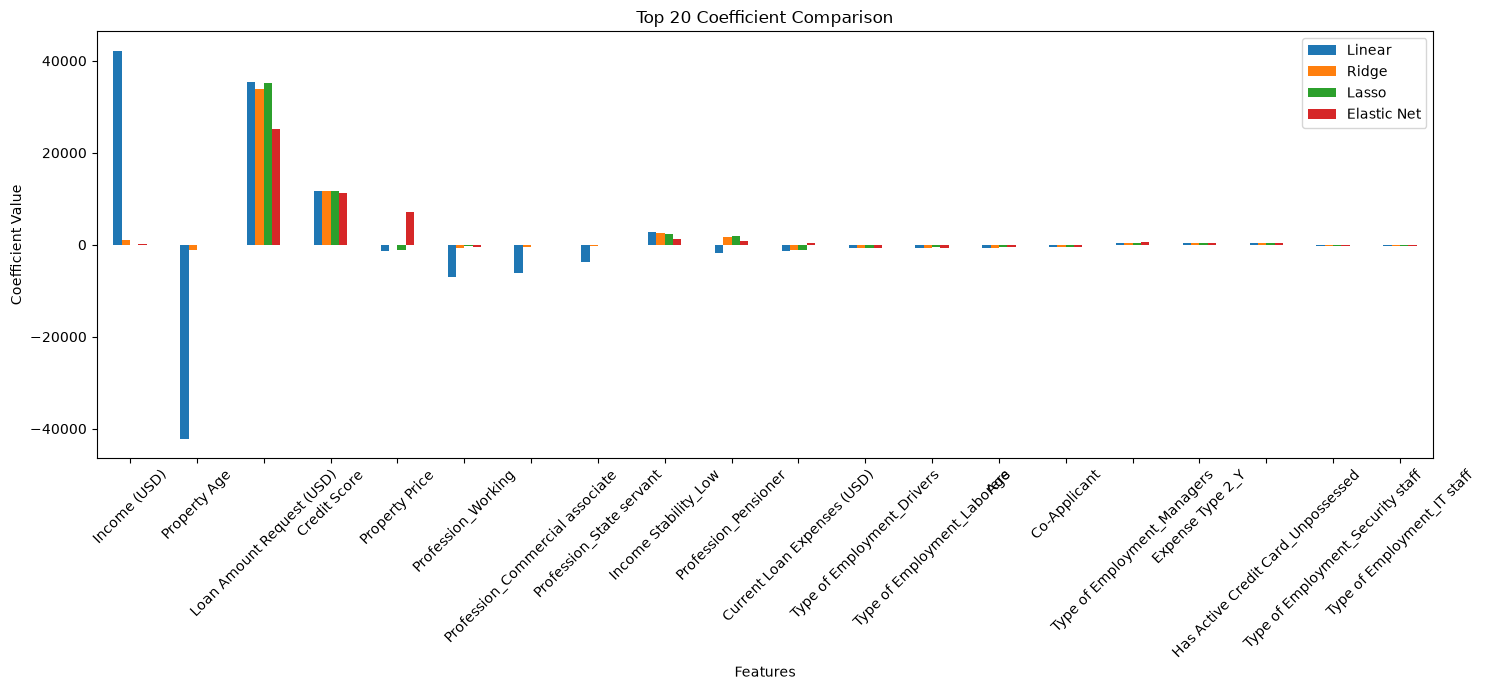

In [97]:
# Select Top 20 Important Features
top_features = coef_df.abs().max(axis=1).sort_values(ascending=False).head(20).index

plt.figure(figsize=(15,7))

coef_df.loc[top_features].plot(kind='bar', figsize=(15,7))

plt.title("Top 20 Coefficient Comparison")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Predicted vs Actual Values Comparison

Compare the actual target values with the predicted values generated by each regression model.

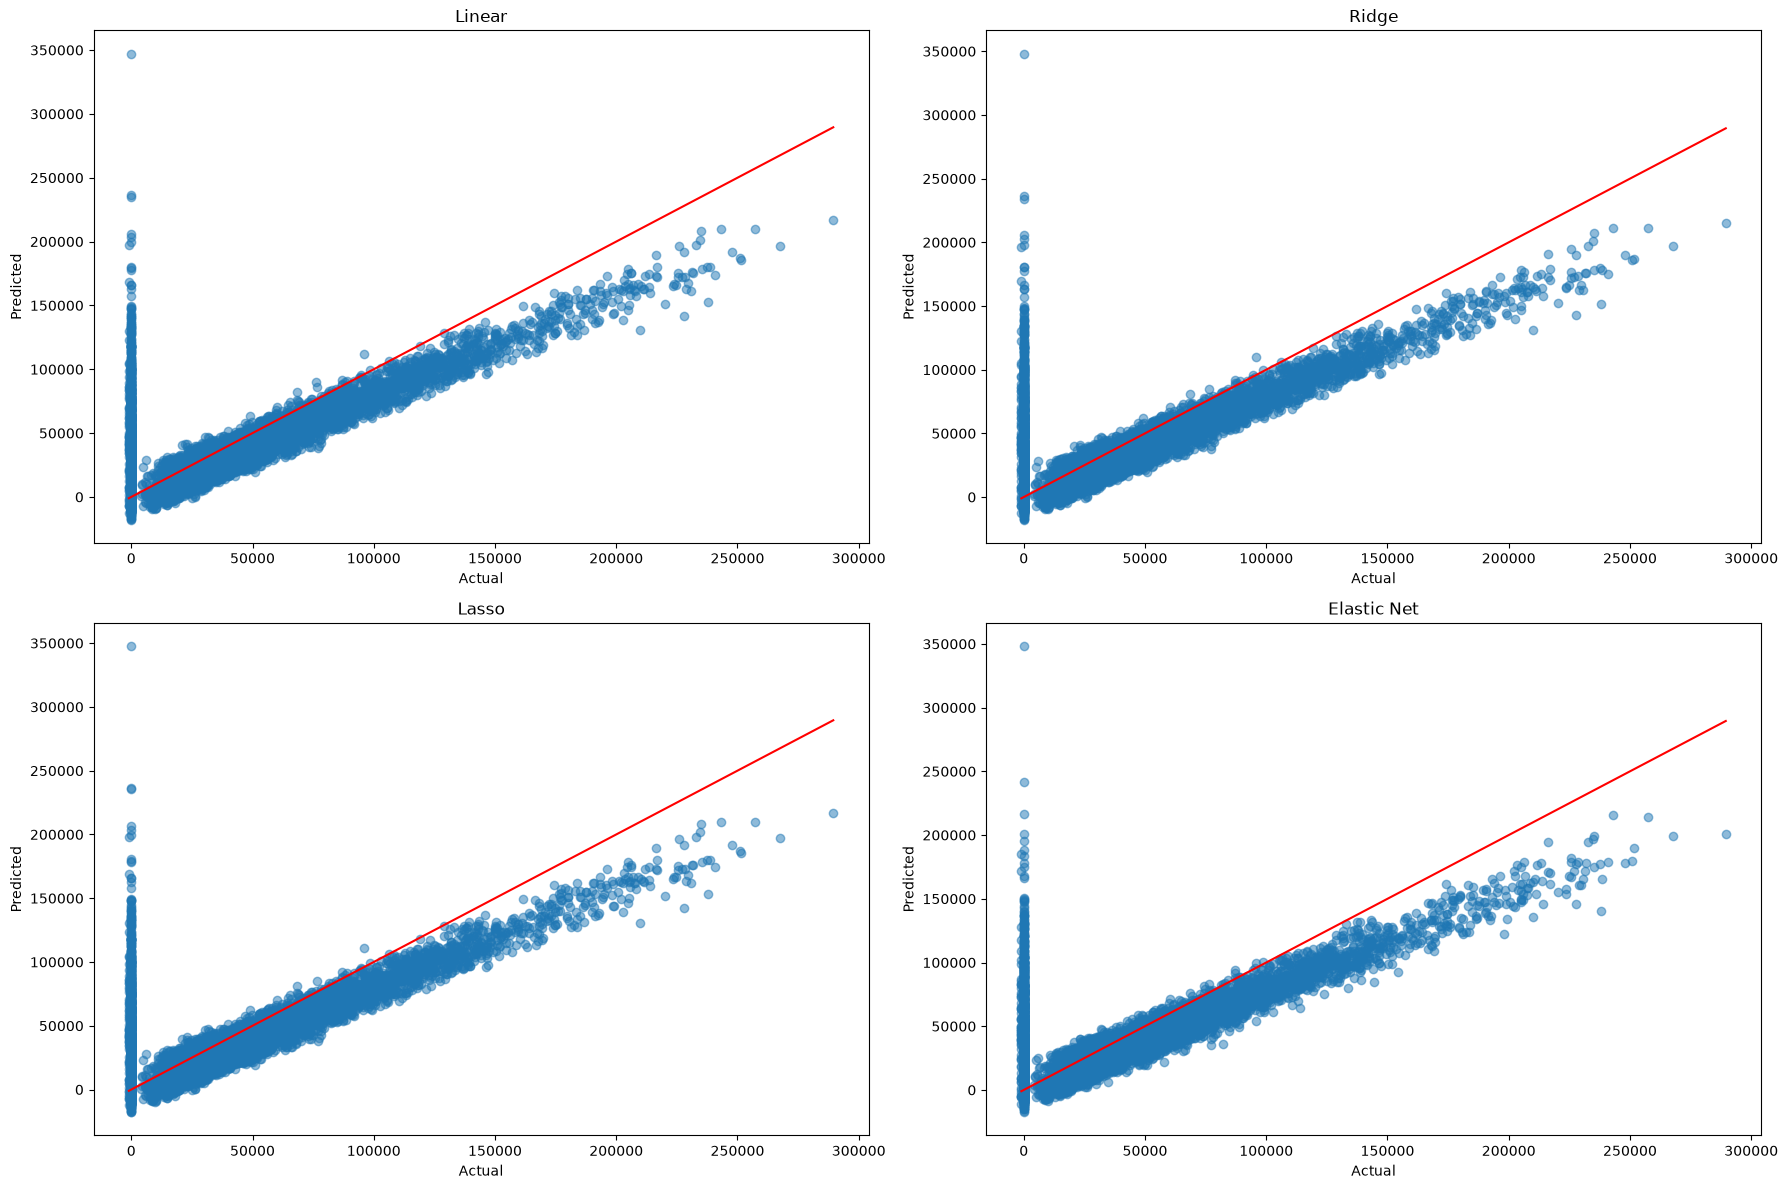

In [98]:

models = {
    "Linear": y_pred_linear,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "Elastic Net": y_pred_elastic
}

plt.figure(figsize=(18,12))

for i, (name, prediction) in enumerate(models.items()):
    
    plt.subplot(2,2,i+1)
    
    plt.scatter(y_test, prediction, alpha=0.5)

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red'
    )

    plt.title(name)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

# Residual Comparison

Visualize the residuals of all regression models to analyze prediction errors.

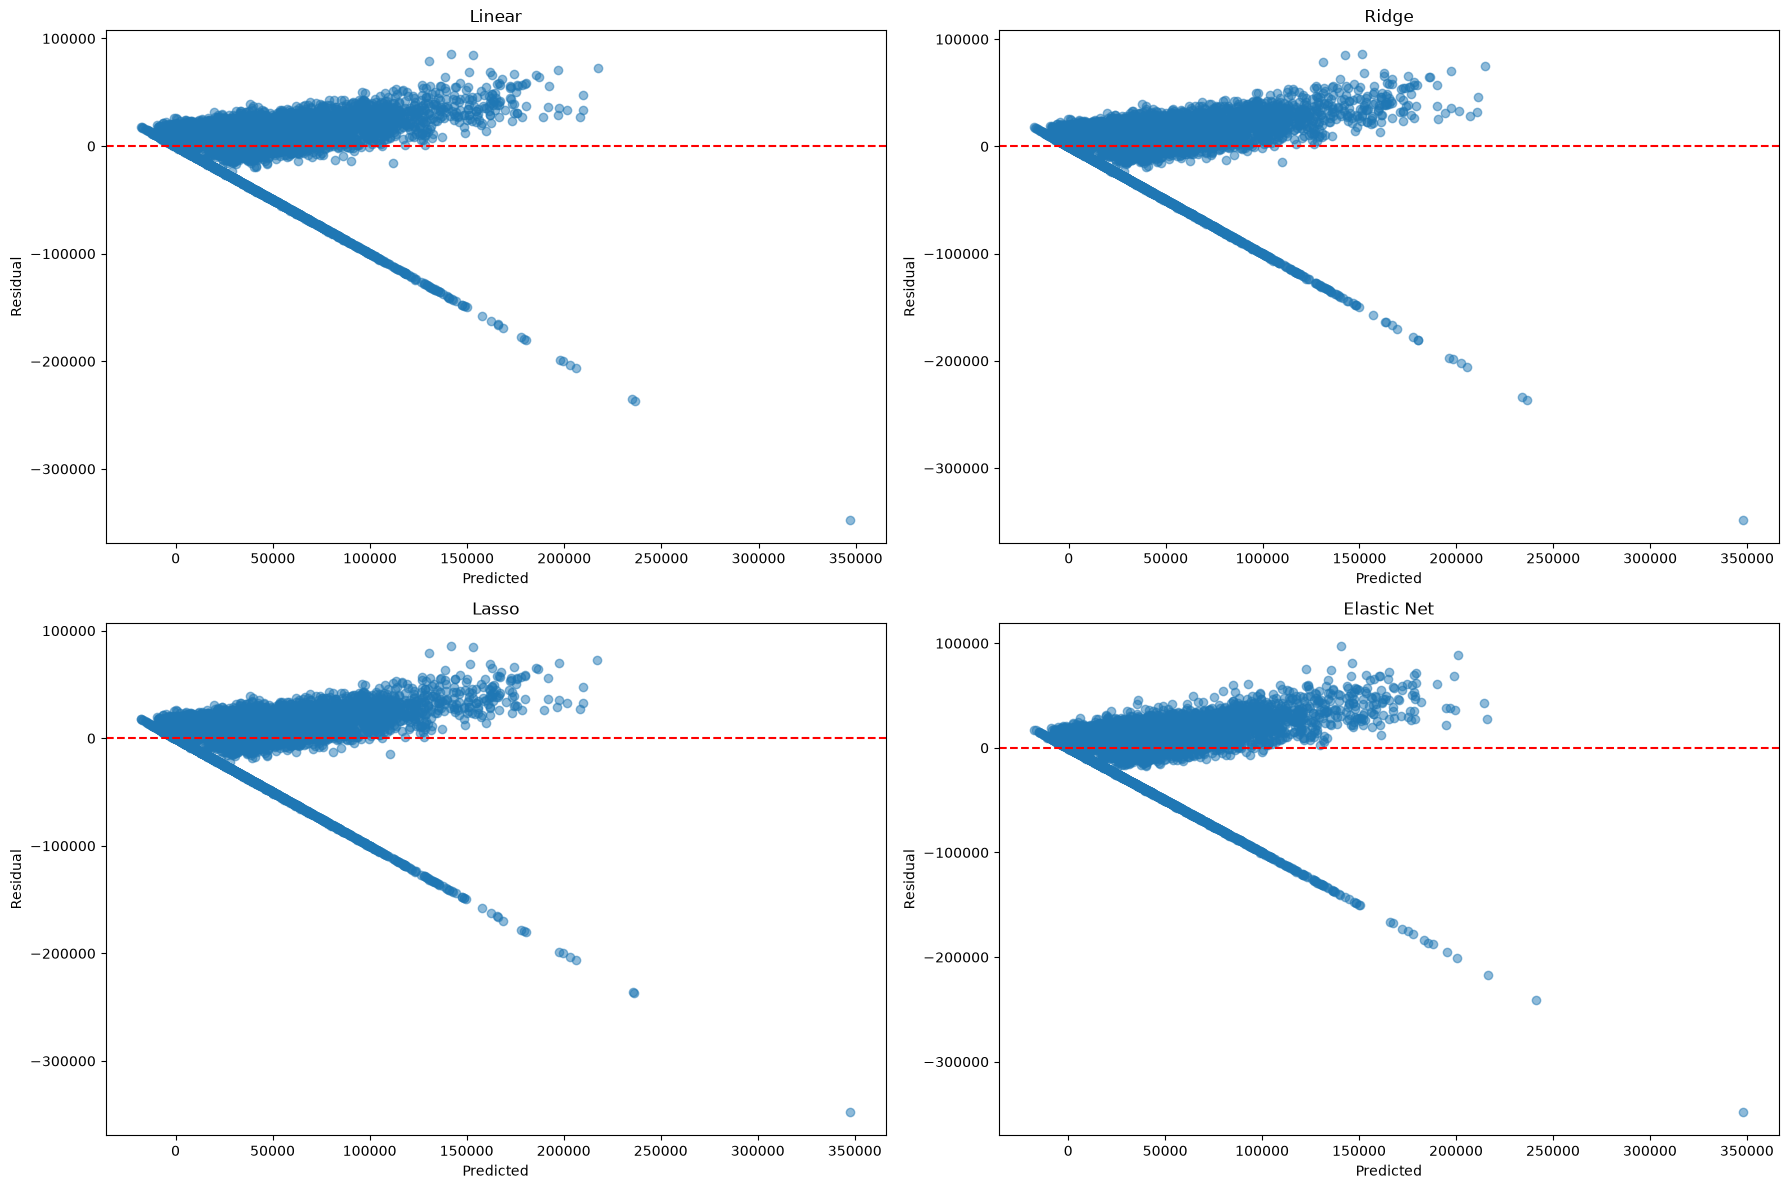

In [99]:


plt.figure(figsize=(18,12))

predictions = {
    "Linear": y_pred_linear,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "Elastic Net": y_pred_elastic
}

for i,(name,pred) in enumerate(predictions.items()):
    
    residuals = y_test - pred

    plt.subplot(2,2,i+1)

    plt.scatter(pred,residuals,alpha=0.5)

    plt.axhline(0,color='red',linestyle='--')

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Residual")

plt.tight_layout()
plt.show()

# Training Error vs Validation Error

Compare the training and testing R² scores to analyze the generalization performance of the regression models.

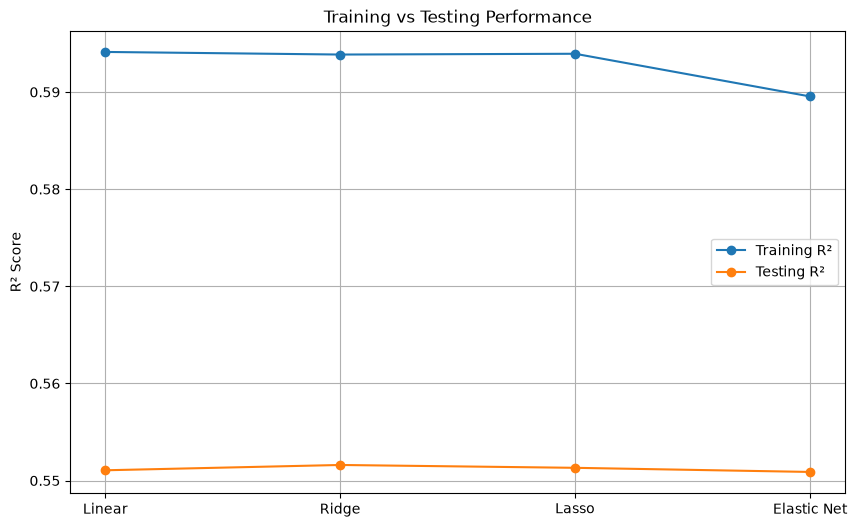

In [100]:


training_scores = [
    linear_model.score(X_train,y_train),
    best_ridge.score(X_train,y_train),
    best_lasso.score(X_train,y_train),
    best_elastic.score(X_train,y_train)
]

testing_scores = [
    linear_model.score(X_test,y_test),
    best_ridge.score(X_test,y_test),
    best_lasso.score(X_test,y_test),
    best_elastic.score(X_test,y_test)
]

models = [
    "Linear",
    "Ridge",
    "Lasso",
    "Elastic Net"
]

plt.figure(figsize=(10,6))

plt.plot(models,training_scores,marker='o',label='Training R²')
plt.plot(models,testing_scores,marker='o',label='Testing R²')

plt.ylabel("R² Score")
plt.title("Training vs Testing Performance")

plt.legend()
plt.grid(True)

plt.show()

# Overfitting and Underfitting Analysis

In [101]:
print("="*60)

for i,model in enumerate(models):

    gap = training_scores[i]-testing_scores[i]

    print(f"{model}")

    print(f"Training R² : {training_scores[i]:.4f}")
    print(f"Testing R²  : {testing_scores[i]:.4f}")

    if gap>0.10:
        print("Observation : Model shows signs of Overfitting")

    elif testing_scores[i]<0.50:
        print("Observation : Model may be Underfitting")

    else:
        print("Observation : Good Generalization")

    print("-"*60)

Linear
Training R² : 0.5941
Testing R²  : 0.5511
Observation : Good Generalization
------------------------------------------------------------
Ridge
Training R² : 0.5939
Testing R²  : 0.5516
Observation : Good Generalization
------------------------------------------------------------
Lasso
Training R² : 0.5939
Testing R²  : 0.5513
Observation : Good Generalization
------------------------------------------------------------
Elastic Net
Training R² : 0.5895
Testing R²  : 0.5509
Observation : Good Generalization
------------------------------------------------------------


# Bias-Variance Analysis

In [102]:
print("="*60)

for i,model in enumerate(models):

    gap=training_scores[i]-testing_scores[i]

    print(model)

    if gap<0.05:
        print("Low Variance")

    else:
        print("High Variance")

    if testing_scores[i]<0.60:
        print("High Bias")

    else:
        print("Low Bias")

    print("-"*60)

Linear
Low Variance
High Bias
------------------------------------------------------------
Ridge
Low Variance
High Bias
------------------------------------------------------------
Lasso
Low Variance
High Bias
------------------------------------------------------------
Elastic Net
Low Variance
High Bias
------------------------------------------------------------


# Best Model Selection

In [104]:
best_model = comparison_df.loc[comparison_df["R² Score"].idxmax()]

print("="*60)

print("Best Performing Model")

print(best_model)

print("="*60)

Best Performing Model
Model                Ridge Regression
MAE                        21588.9183
MSE                   1017752734.8403
RMSE                       31902.2371
R² Score                       0.5516
Training Time (s)              0.0305
Name: 1, dtype: object


# Conclusion

In [106]:
print("""
1. Linear Regression was used as the baseline model.

2. Ridge Regression reduced coefficient magnitudes and improved
   generalization through L2 regularization.

3. Lasso Regression performed feature selection by shrinking
   less important coefficients toward zero.

4. Elastic Net combined both L1 and L2 regularization.

5. Hyperparameter tuning using GridSearchCV improved the
   overall performance of the regularized models.

6. The best-performing model was selected based on the
   highest R² score and the lowest prediction errors.
""")


1. Linear Regression was used as the baseline model.

2. Ridge Regression reduced coefficient magnitudes and improved
   generalization through L2 regularization.

3. Lasso Regression performed feature selection by shrinking
   less important coefficients toward zero.

4. Elastic Net combined both L1 and L2 regularization.

5. Hyperparameter tuning using GridSearchCV improved the
   overall performance of the regularized models.

6. The best-performing model was selected based on the
   highest R² score and the lowest prediction errors.

